# Hotel Booking Survey Analysis

## Task description

Imagine that you own a hotel booking service and have conducted a customer survey.  
A description of the evaluation criteria is provided on the first sheet.

Your task is to perform a quick analysis of the survey results. Below is a set of basic tasks that should be completed using **pandas**. The final answer should be presented as a **Jupyter Notebook** with a clear step-by-step solution.

### Tasks

1. Read the data using **pandas**.
2. Segment each score into **NPS-style groups** (*detractor, promoter, passive*) and define the threshold values used for the segmentation.
3. Show how factor importance changed by quarter, considering only the most important responses (*Important* and *Critically important*).

#### Example of the final table structure

| Factors  | Q3 2023 | Q4 2023 |
|----------|---------|---------|
| Factor 1 | Value   | Value   |

4. Show the number of **detractors, promoters, and passive** by quarter.

#### Example of the final table structure

| Factors  | Q3 2023 Detractor | Q3 2023 Promoter | Q3 2023 Passive | Q3 2023 No response | Q4 2023 Detractor | Q4 2023 Promoter | Q4 2023 Passive | Q4 2023 No response |
|----------|-------------------|------------------|-----------------|---------------------|-------------------|------------------|-----------------|---------------------|
| Factor 1 | Value             | Value            | Value           | Value               | Value             | Value            | Value           | Value               |

## Imports

In [1829]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [1830]:
DATA_FILE_NAME = 'data.csv'

## Load data

In [1831]:
df = pd.read_csv(DATA_FILE_NAME)
df.head()

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,less_than_6_months,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,6_to_12_months,7,7,9,8,cannot_evaluate,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,6_to_12_months,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,less_than_6_months,8,5,cannot_evaluate,cannot_evaluate,cannot_evaluate,cannot_evaluate,cannot_evaluate,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,6_to_12_months,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1832]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   response_id                                   57 non-null     int64 
 1   created_at                                    57 non-null     object
 2   service_usage_duration                        57 non-null     object
 3   overall_satisfaction                          57 non-null     int64 
 4   website_app_usability                         57 non-null     object
 5   processing_speed                              57 non-null     object
 6   variety_of_offers                             57 non-null     object
 7   service_quality                               57 non-null     object
 8   price_to_quality_ratio                        57 non-null     object
 9   reviews_ratings_convenience                   57 non-null     object
 10  hote

The dataset contains 1 missing value

In [1833]:
df.describe()

,response_id,overall_satisfaction
count,5.700000e+01,57.000000
mean,1.497342e+09,7.578947
std,6.718552e+07,1.362080
min,1.437281e+09,4.000000
25%,1.438733e+09,7.000000
50%,1.439024e+09,8.000000
75%,1.570926e+09,8.000000
max,1.578157e+09,10.000000


In [1834]:
df[df.duplicated()]

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance


In [1835]:
df[df['response_id'].duplicated()]

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance


No duplicate rows or duplicate response_id values were found

## Data preparation

Let’s take a look at the data in the columns.

Columns 4–12 contain factor evaluation scores, while columns 13–21 contain factor importance ratings.

In [1836]:
pd.set_option("display.max_colwidth", None)

column_summary = pd.DataFrame({
    "column": [
        "service_usage_duration",
        "overall_satisfaction",
        "factor_score_columns (4-12)",
        "importance_columns (13-21)",
    ],
    "unique_values": [
        sorted(df["service_usage_duration"].astype(str).unique().tolist()),
        sorted(df["overall_satisfaction"].unique().tolist()),
        sorted(df.iloc[:, 4:13].stack(dropna=False).unique(), key=str),
        sorted(df.iloc[:, 13:22].stack(dropna=False).unique(), key=str),
    ]
})

column_summary

,column,unique_values
0,service_usage_duration,"[1_to_2_years, 6_to_12_months, less_than_6_months, more_than_2_years]"
1,overall_satisfaction,"[4, 5, 6, 7, 8, 9, 10]"
2,factor_score_columns (4-12),"[1, 10, 2, 3, 4, 5, 6, 7, 8, 9, cannot_evaluate, nan]"
3,importance_columns (13-21),"[cannot_evaluate, critically_important, important, neutral, not_important, not_important_at_all]"


In [1837]:
df.iloc[:, 13:22].stack(dropna=False).value_counts(dropna=False)

important               233
critically_important    174
neutral                  71
cannot_evaluate          17
not_important            11
not_important_at_all      7
Name: count, dtype: int64

In [1838]:
df.iloc[:, 4:13].stack(dropna=False).value_counts(dropna=False)

8                  84
7                  73
9                  70
cannot_evaluate    60
6                  52
10                 39
3                  39
5                  35
4                  31
1                  16
2                  13
NaN                 1
Name: count, dtype: int64

We have 77 'cannot_evaluate' answers which are nan

In [1839]:
df = df.replace('cannot_evaluate', pd.NA)
df.head()

,response_id,created_at,service_usage_duration,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,less_than_6_months,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,6_to_12_months,7,7,9,8,<NA>,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,6_to_12_months,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,less_than_6_months,8,5,<NA>,<NA>,<NA>,<NA>,<NA>,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,6_to_12_months,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


Let's check the type of `created_at` column

In [1840]:
df['created_at'].dtype

dtype('O')

`created_at` is stored as an object, so it needs to be converted to datetime.

In [1841]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [1842]:
df['created_at'].dtype

dtype('<M8[ns]')

In [1843]:
df['quarter'] = df['created_at'].dt.to_period('Q')
base_cols = ['response_id', 'created_at', 'quarter']
factor_cols = [
    'overall_satisfaction',
    'website_app_usability',
    'processing_speed',
    'variety_of_offers',
    'service_quality',
    'price_to_quality_ratio',
    'reviews_ratings_convenience',
    'hotel_info_quality_relevance',
    'payment_security',
    'booking_cancellation_modification'
]
importance_cols = [
    'website_app_usability_importance',
    'processing_speed_importance',
    'variety_of_offers_importance',
    'service_quality_importance',
    'price_to_quality_ratio_importance',
    'reviews_ratings_convenience_importance',
    'hotel_info_quality_relevance_importance',
    'payment_security_importance',
    'booking_cancellation_modification_importance'
]

analysis_df = df[base_cols + factor_cols + importance_cols].copy()

analysis_df.head()

,response_id,created_at,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,2023Q4,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,2023Q4,7,7,9,8,<NA>,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,2023Q4,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,2023Q4,8,5,<NA>,<NA>,<NA>,<NA>,<NA>,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,2023Q4,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1844]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 22 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   response_id                                   57 non-null     int64         
 1   created_at                                    57 non-null     datetime64[ns]
 2   quarter                                       57 non-null     period[Q-DEC] 
 3   overall_satisfaction                          57 non-null     int64         
 4   website_app_usability                         55 non-null     object        
 5   processing_speed                              53 non-null     object        
 6   variety_of_offers                             54 non-null     object        
 7   service_quality                               44 non-null     object        
 8   price_to_quality_ratio                        50 non-null     object    

## NPS segmentation

The goal of this section is to segment users based on their likelihood to recommend the product and identify the main drivers of dissatisfaction.

We will divide them into groups according to the [standard approach](https://en.wikipedia.org/wiki/Net_promoter_score): 9–10 points – promoter, 7–8 points – passive, 0–6 points – detractor:

In [1845]:
analysis_df.head()

,response_id,created_at,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,...,booking_cancellation_modification,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023-12-20 13:05:42,2023Q4,9,9,7,4,5,7,10,...,10,important,important,important,important,important,important,critically_important,important,not_important
1,1578147391,2023-12-20 12:55:48,2023Q4,7,7,9,8,<NA>,8,8,...,6,critically_important,critically_important,critically_important,neutral,important,neutral,important,neutral,not_important
2,1578000638,2023-12-20 10:21:21,2023Q4,8,6,8,8,7,6,9,...,9,critically_important,critically_important,critically_important,critically_important,important,neutral,neutral,important,neutral
3,1577923109,2023-12-20 08:49:31,2023Q4,8,5,<NA>,<NA>,<NA>,<NA>,<NA>,...,10,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important,critically_important
4,1576069400,2023-12-18 11:12:16,2023Q4,8,5,5,3,3,5,6,...,4,critically_important,critically_important,critically_important,important,critically_important,important,neutral,neutral,important


In [1846]:
nps_scores = analysis_df[['response_id', 'quarter'] + factor_cols].copy()
nps_scores.head()


,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,9,9,7,4,5,7,10,10,10,10
1,1578147391,2023Q4,7,7,9,8,<NA>,8,8,8,6,6
2,1578000638,2023Q4,8,6,8,8,7,6,9,9,10,9
3,1577923109,2023Q4,8,5,<NA>,<NA>,<NA>,<NA>,<NA>,10,<NA>,10
4,1576069400,2023Q4,8,5,5,3,3,5,6,6,6,4


In [1847]:
def map_nps_status(value):
    if pd.isna(value):
        return pd.NA
    
    value = int(value)

    if value >= 9:
        return 'promoter'
    elif value >= 7:
        return 'passive'
    else:
        return 'detractor'

In [1848]:
nps_scores[factor_cols] = nps_scores[factor_cols].applymap(map_nps_status)

nps_scores.head()

,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,promoter,promoter,passive,detractor,detractor,passive,promoter,promoter,promoter,promoter
1,1578147391,2023Q4,passive,passive,promoter,passive,<NA>,passive,passive,passive,detractor,detractor
2,1578000638,2023Q4,passive,detractor,passive,passive,passive,detractor,promoter,promoter,promoter,promoter
3,1577923109,2023Q4,passive,detractor,<NA>,<NA>,<NA>,<NA>,<NA>,promoter,<NA>,promoter
4,1576069400,2023Q4,passive,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor


In [1849]:
overall_nps_distribution = (nps_scores['overall_satisfaction']
    .value_counts(dropna=False)
    .rename_axis('category')
    .reset_index(name='count')
    )
overall_nps_distribution['share'] = (overall_nps_distribution['count'] / overall_nps_distribution['count'].sum())

overall_nps_distribution

,category,count,share
0,passive,36,0.631579
1,promoter,11,0.192982
2,detractor,10,0.175439


The overall NPS distribution is dominated by passive users, indicating that the product is perceived as acceptable but does not generate strong loyalty or advocacy.

In [1850]:
factor_nps_distribution = nps_scores.iloc[:, 2:].stack().value_counts().reset_index()
factor_nps_distribution.columns = ['category', 'count']
factor_nps_distribution['share'] = factor_nps_distribution['count'] / factor_nps_distribution['count'].sum()

factor_nps_distribution

,category,count,share
0,detractor,196,0.385069
1,passive,193,0.379175
2,promoter,120,0.235756


At the factor level, detractors make up the largest share of responses, suggesting that users are considerably more critical when evaluating specific aspects of the product than when rating the experience overall

In [1851]:
overall_nps_shares = nps_scores.iloc[:, 1].value_counts(normalize=True)

overall_nps = round((overall_nps_shares.get('promoter', 0) - overall_nps_shares.get('detractor', 0)) * 100, 2)
overall_nps

0

Despite the high share of passive users, the overall NPS remains close to zero, meaning that promoters only slightly outnumber detractors. This suggests that the product does not generate strong positive sentiment or loyalty. At the same time, factor-level analysis reveals a substantially higher share of detractors, indicating hidden dissatisfaction with specific aspects of the user experience

In [1852]:
nps_cols = nps_scores.columns[2:]

factor_detractor_share = (
    (nps_scores[nps_cols] == 'detractor').sum() /
    nps_scores[nps_cols].notna().sum()
)

factor_detractor_share = factor_detractor_share.reset_index()
factor_detractor_share.columns = ['factor', 'detractor_share']

factor_detractor_share['detractor_share'] *= 100

factor_detractor_share = factor_detractor_share.sort_values(
    by='detractor_share',
    ascending=False
)

factor_detractor_share

,factor,detractor_share
4,service_quality,70.454545
1,website_app_usability,61.818182
3,variety_of_offers,48.148148
5,price_to_quality_ratio,42.000000
9,booking_cancellation_modification,41.860465
2,processing_speed,41.509434
8,payment_security,28.000000
7,hotel_info_quality_relevance,20.754717
6,reviews_ratings_convenience,18.000000
0,overall_satisfaction,17.543860


In [1853]:
factor_nps_share_table = pd.concat(
    [
        nps_scores[col].value_counts(normalize=True).rename(col)
        for col in nps_cols
    ],
    axis=1
).T.fillna(0)

factor_nps_share_table = factor_nps_share_table.sort_values(
    by='detractor',
    ascending=False
)

factor_nps_share_table = (factor_nps_share_table * 100).round(2)

factor_nps_share_table

,passive,promoter,detractor
service_quality,20.45,9.09,70.45
website_app_usability,30.91,7.27,61.82
variety_of_offers,42.59,9.26,48.15
price_to_quality_ratio,42.00,16.00,42.00
booking_cancellation_modification,18.60,39.53,41.86
processing_speed,45.28,13.21,41.51
payment_security,32.00,40.00,28.00
hotel_info_quality_relevance,30.19,49.06,20.75
reviews_ratings_convenience,46.00,36.00,18.00
overall_satisfaction,63.16,19.30,17.54


The product performs relatively well in informational and trust-related areas, such as hotel information quality, reviews, and payment security. However, it underperforms in core experience areas — especially usability and service quality — where the share of detractors is the highest

This gap suggests that while users trust the platform and find the content useful, the core interaction and service experience still create significant friction

## Analysis of important factors by quarter

We analyzed how the importance of key product factors changed over time.

Only responses marked as ‘important’ or ‘critically important’ were considered

In [1854]:
importance_df = analysis_df[['response_id', 'quarter'] + importance_cols]
importance_df[importance_cols] = importance_df[importance_cols].map(
    lambda x: 1 if pd.notna(x) and x in ['important', 'critically_important'] else 0
)
importance_df.head()

,response_id,quarter,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
0,1578157017,2023Q4,1,1,1,1,1,1,1,1,0
1,1578147391,2023Q4,1,1,1,0,1,0,1,0,0
2,1578000638,2023Q4,1,1,1,1,1,0,0,1,0
3,1577923109,2023Q4,1,1,1,1,1,1,1,1,1
4,1576069400,2023Q4,1,1,1,1,1,1,0,0,1


In [1855]:
quarterly_importance_count = importance_df.groupby('quarter')[importance_cols].sum()
quarterly_importance_share = quarterly_importance_count.div(
    quarterly_importance_count.sum(axis=1), axis=0
) * 100

quarterly_importance_count

,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
quarter,,,,,,,,,
2023Q3,31,31,28,23,28,21,23,17,18
2023Q4,25,25,25,20,20,20,21,15,16


In [1856]:
quarterly_importance_summary = quarterly_importance_count.copy()

for col in quarterly_importance_count.columns:
    pct = quarterly_importance_count[col] / quarterly_importance_count.sum(axis=1) * 100
    
    quarterly_importance_summary[col] = (
        quarterly_importance_count[col].astype(int).astype(str)
        + ' ('
        + pct.map('{:.2f}%'.format)
        + ')'
    )
    
quarterly_importance_summary

,website_app_usability_importance,processing_speed_importance,variety_of_offers_importance,service_quality_importance,price_to_quality_ratio_importance,reviews_ratings_convenience_importance,hotel_info_quality_relevance_importance,payment_security_importance,booking_cancellation_modification_importance
quarter,,,,,,,,,
2023Q3,31 (14.09%),31 (14.09%),28 (12.73%),23 (10.45%),28 (12.73%),21 (9.55%),23 (10.45%),17 (7.73%),18 (8.18%)
2023Q4,25 (13.37%),25 (13.37%),25 (13.37%),20 (10.70%),20 (10.70%),20 (10.70%),21 (11.23%),15 (8.02%),16 (8.56%)


Quarterly importance analysis shows that website/app usability and processing speed remained the most important factors in both periods. At the same time, the relative importance of variety of offers and hotel information slightly increased in 2023Q4, while price-to-quality ratio became somewhat less important. Overall, user priorities remained fairly stable across quarters.

Since web/app usability and processing speed are consistently among the most important factors, improvements in these areas are likely to have the strongest impact on overall user satisfaction.

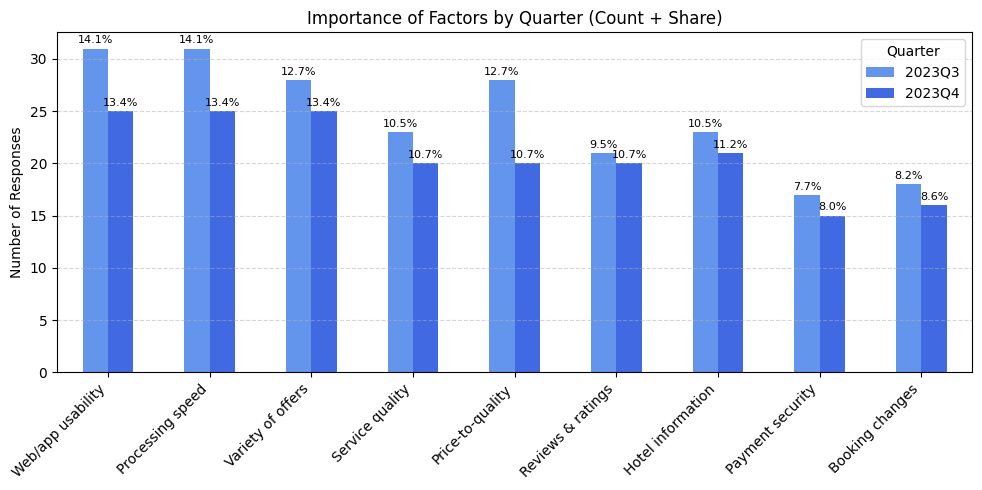

In [1857]:
rename_importance_dict = {
    'website_app_usability_importance': 'Web/app usability',
    'processing_speed_importance': 'Processing speed',
    'variety_of_offers_importance': 'Variety of offers',
    'service_quality_importance': 'Service quality',
    'price_to_quality_ratio_importance': 'Price-to-quality',
    'reviews_ratings_convenience_importance': 'Reviews & ratings',
    'hotel_info_quality_relevance_importance': 'Hotel information',
    'payment_security_importance': 'Payment security',
    'booking_cancellation_modification_importance': 'Booking changes'
}

importance_renamed = quarterly_importance_count.rename(columns=rename_importance_dict)
importance_rel_renamed = quarterly_importance_share.rename(columns=rename_importance_dict)

ax = importance_renamed.T.plot.bar(
    figsize=(10, 5),
    color=["cornflowerblue", "royalblue"]
)

for container, quarter in zip(ax.containers, importance_rel_renamed.index):
    for bar, pct in zip(container, importance_rel_renamed.loc[quarter]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{pct:.1f}%',
            ha='center',
            fontsize=8
        )

plt.ylabel('Number of Responses')
plt.title('Importance of Factors by Quarter (Count + Share)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Quarter')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Usability is both highly important and highly problematic, while service quality stands out as one of the strongest dissatisfaction drivers. Together, these factors reveal a critical gap between user expectations and actual product experience

## Analysis of detractor / promoters / passive by quarter

In this section, we analyze how the distribution of NPS categories (both counts and shares) evolves across quarters for each factor to capture both the scale and the relative structure of user feedback

In [1858]:
nps_scores.head()

,response_id,quarter,overall_satisfaction,website_app_usability,processing_speed,variety_of_offers,service_quality,price_to_quality_ratio,reviews_ratings_convenience,hotel_info_quality_relevance,payment_security,booking_cancellation_modification
0,1578157017,2023Q4,promoter,promoter,passive,detractor,detractor,passive,promoter,promoter,promoter,promoter
1,1578147391,2023Q4,passive,passive,promoter,passive,<NA>,passive,passive,passive,detractor,detractor
2,1578000638,2023Q4,passive,detractor,passive,passive,passive,detractor,promoter,promoter,promoter,promoter
3,1577923109,2023Q4,passive,detractor,<NA>,<NA>,<NA>,<NA>,<NA>,promoter,<NA>,promoter
4,1576069400,2023Q4,passive,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor,detractor


In [1859]:
nps_scores_factor_status = nps_scores[['quarter', 'overall_satisfaction'] + factor_cols]
nps_scores_factor_status = nps_scores_factor_status.melt(id_vars=['quarter'], var_name='factors', value_name='status')
nps_scores_factor_status.head()

,quarter,factors,status
0,2023Q4,overall_satisfaction,promoter
1,2023Q4,overall_satisfaction,passive
2,2023Q4,overall_satisfaction,passive
3,2023Q4,overall_satisfaction,passive
4,2023Q4,overall_satisfaction,passive


In [1860]:
nps_scores_factor_status["status"] = (
    nps_scores_factor_status["status"]
    .fillna("no_response")
)

status_order = ["detractor", "promoter", "passive", "no_response"]
quarter_order = sorted(nps_scores_factor_status["quarter"].dropna().unique())

quarterly_nps_status_counts = pd.pivot_table(nps_scores_factor_status, 
                             index=['factors'], 
                             columns=['quarter', 'status'], 
                             aggfunc='size', 
                             fill_value=0)

quarterly_nps_status_counts = quarterly_nps_status_counts.reindex(
    columns=pd.MultiIndex.from_product([quarter_order, status_order]),
    fill_value=0
)


factor_order = [
    "website_app_usability",
    "processing_speed",
    "variety_of_offers",
    "service_quality",
    "price_to_quality_ratio",
    "reviews_ratings_convenience",
    "hotel_info_quality_relevance",
    "payment_security",
    "booking_cancellation_modification",
    "overall_satisfaction",
]

quarterly_nps_status_counts = quarterly_nps_status_counts.reindex(factor_order)
quarterly_nps_status_counts


2023Q3                               \
                                  detractor promoter passive no_response   
factors                                                                    
website_app_usability                    21        2       7           2   
processing_speed                          9        3      17           3   
variety_of_offers                        14        2      14           2   
service_quality                          17        2       7           6   
price_to_quality_ratio                   10        5      13           4   
reviews_ratings_convenience               5       10      12           5   
hotel_info_quality_relevance              6       16       7           3   
payment_security                          8       10      10           4   
booking_cancellation_modification        10        8       6           8   
overall_satisfaction                     14       12      38           0   

                                     2023Q4                               
                                  detractor promoter passive no_response  
factors                                                                   
website_app_usability                    13        2      10           0  
processing_speed                         13        4       7           1  
variety_of_offers                        12        3       9           1  
service_quality                          14        2       2           7  
price_to_quality_ratio                   11        3       8           3  
reviews_ratings_convenience               4        8      11           2  
hotel_info_quality_relevance              5       10       9           1  
payment_security                          6       10       6           3  
booking_cancellation_modification         8        9       2           6  
overall_satisfaction                      6       10      34           0

- **Website / app usability** had the highest number of detractor scores in both quarters, although the count decreased in Q4 2023.
- **Service quality**, **variety of offers**, and **price-to-quality ratio** also showed relatively high detractor counts compared to other factors.
- **Hotel information quality and relevance** had one of the most positive distributions, with promoter scores consistently exceeding detractor scores.
- **Overall satisfaction** was dominated by passive responses in both quarters, indicating that many respondents gave mid-range rather than extreme evaluations.

In [1861]:
quarterly_nps_status_share = pd.concat(
    {
        quarter: quarterly_nps_status_counts[quarter].div(
            quarterly_nps_status_counts[quarter].sum(axis=1),
            axis=0
        )
        for quarter in quarterly_nps_status_counts.columns.get_level_values(0).unique()
    },
    axis=1
).mul(100).round(2)

quarterly_nps_status_share

2023Q3                               \
                                  detractor promoter passive no_response   
factors                                                                    
website_app_usability                 65.62     6.25   21.88        6.25   
processing_speed                      28.12     9.38   53.12        9.38   
variety_of_offers                     43.75     6.25   43.75        6.25   
service_quality                       53.12     6.25   21.88       18.75   
price_to_quality_ratio                31.25    15.62   40.62       12.50   
reviews_ratings_convenience           15.62    31.25   37.50       15.62   
hotel_info_quality_relevance          18.75    50.00   21.88        9.38   
payment_security                      25.00    31.25   31.25       12.50   
booking_cancellation_modification     31.25    25.00   18.75       25.00   
overall_satisfaction                  21.88    18.75   59.38        0.00   

                                     2023Q4                               
                                  detractor promoter passive no_response  
factors                                                                   
website_app_usability                  52.0      8.0    40.0         0.0  
processing_speed                       52.0     16.0    28.0         4.0  
variety_of_offers                      48.0     12.0    36.0         4.0  
service_quality                        56.0      8.0     8.0        28.0  
price_to_quality_ratio                 44.0     12.0    32.0        12.0  
reviews_ratings_convenience            16.0     32.0    44.0         8.0  
hotel_info_quality_relevance           20.0     40.0    36.0         4.0  
payment_security                       24.0     40.0    24.0        12.0  
booking_cancellation_modification      32.0     36.0     8.0        24.0  
overall_satisfaction                   12.0     20.0    68.0         0.0

In [1862]:
quarterly_nps_status_combined = quarterly_nps_status_counts.copy()

for quarter in quarterly_nps_status_counts.columns.get_level_values(0).unique():
    for status in quarterly_nps_status_counts[quarter].columns:
        counts = quarterly_nps_status_counts[(quarter, status)]
        shares = quarterly_nps_status_share[(quarter, status)]
        
        quarterly_nps_status_combined[(quarter, status)] = (
            counts.astype(int).astype(str)
            + " ("
            + shares.round(1).astype(str)
            + "%)"
        )

quarterly_nps_status_combined

2023Q3                          \
                                    detractor    promoter     passive   
factors                                                                 
website_app_usability              21 (65.6%)    2 (6.2%)   7 (21.9%)   
processing_speed                    9 (28.1%)    3 (9.4%)  17 (53.1%)   
variety_of_offers                  14 (43.8%)    2 (6.2%)  14 (43.8%)   
service_quality                    17 (53.1%)    2 (6.2%)   7 (21.9%)   
price_to_quality_ratio             10 (31.2%)   5 (15.6%)  13 (40.6%)   
reviews_ratings_convenience         5 (15.6%)  10 (31.2%)  12 (37.5%)   
hotel_info_quality_relevance        6 (18.8%)  16 (50.0%)   7 (21.9%)   
payment_security                    8 (25.0%)  10 (31.2%)  10 (31.2%)   
booking_cancellation_modification  10 (31.2%)   8 (25.0%)   6 (18.8%)   
overall_satisfaction               14 (21.9%)  12 (18.8%)  38 (59.4%)   

                                                   2023Q4              \
                                  no_response   detractor    promoter   
factors                                                                 
website_app_usability                2 (6.2%)  13 (52.0%)    2 (8.0%)   
processing_speed                     3 (9.4%)  13 (52.0%)   4 (16.0%)   
variety_of_offers                    2 (6.2%)  12 (48.0%)   3 (12.0%)   
service_quality                     6 (18.8%)  14 (56.0%)    2 (8.0%)   
price_to_quality_ratio              4 (12.5%)  11 (44.0%)   3 (12.0%)   
reviews_ratings_convenience         5 (15.6%)   4 (16.0%)   8 (32.0%)   
hotel_info_quality_relevance         3 (9.4%)   5 (20.0%)  10 (40.0%)   
payment_security                    4 (12.5%)   6 (24.0%)  10 (40.0%)   
booking_cancellation_modification   8 (25.0%)   8 (32.0%)   9 (36.0%)   
overall_satisfaction                 0 (0.0%)   6 (12.0%)  10 (20.0%)   

                                                           
                                      passive no_response  
factors                                                    
website_app_usability              10 (40.0%)    0 (0.0%)  
processing_speed                    7 (28.0%)    1 (4.0%)  
variety_of_offers                   9 (36.0%)    1 (4.0%)  
service_quality                      2 (8.0%)   7 (28.0%)  
price_to_quality_ratio              8 (32.0%)   3 (12.0%)  
reviews_ratings_convenience        11 (44.0%)    2 (8.0%)  
hotel_info_quality_relevance        9 (36.0%)    1 (4.0%)  
payment_security                    6 (24.0%)   3 (12.0%)  
booking_cancellation_modification    2 (8.0%)   6 (24.0%)  
overall_satisfaction               34 (68.0%)    0 (0.0%)

Core experience factors remain the main drivers of dissatisfaction.
Usability shows some improvement, but still has a high share of detractors.
Service quality slightly deteriorated, while processing speed shows the most significant decline, with users shifting from passive to detractors.

Price-to-quality ratio also worsened, indicating a drop in perceived value.
In contrast, content and trust-related factors (hotel information, payment security) remain relatively strong.


Quarter-over-quarter analysis shows that core experience factors — usability, service quality, and especially processing speed — remain the primary sources of dissatisfaction. While usability shows some improvement, processing speed has significantly deteriorated, with users shifting from passive to detractor segments.

At the same time, overall satisfaction has improved due to a reduction in detractors, but this has not led to an increase in promoters, suggesting limited growth in user loyalty.

This indicates that while some issues are being mitigated, the product still fails to meet expectations in key interaction areas, which represent the highest opportunity for improving NPS.

## Recommendations

### 1. Prioritize improvements in core experience (highest impact)
Focus on processing speed, service quality, and web/app usability, as these factors combine high importance, a high share of detractors, and negative or weak dynamics.

These areas represent the greatest opportunity to improve NPS.

### 2. Investigate the drop in processing speed

The sharp increase in detractors points to possible degradation in performance or the emergence of new friction points. 

Analyze performance metrics (latency, errors), review recent releases and identify friction points in key user flows.

### 3. Improve service quality consistency

High and growing dissatisfaction indicates systemic issues. 

Analyze user complaints and support tickets, segment by user type or journey.

### 4. Optimize usability to convert passives into promoters

Usability shows improvement, but still has a high share of detractors and many passives. 

Focus on simplifying key flows and improving UI/UX clarity to reduce friction and increase satisfaction.

### 5. Strengthen perceived value (price-to-quality)

Growing dissatisfaction suggests users feel the product is not worth the price. 

Review pricing relative to the offering, improve value communication, and better align expectations with actual experience.

### 6. Leverage strong areas (content & trust)

Factors such as hotel information quality and payment security perform well.

Use them to reinforce trust in the product, support decision-making, and highlight product strengths within the user journey.



***Improving core experience — especially speed, usability, and service quality — is the most effective way to increase NPS by both reducing detractors and converting passive users into promoters.***